In [1]:
# ============================================================
# PHASE 5 — CELL 1: SETUP & STATE RECOVERY
# ============================================================

import os, sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             f1_score, accuracy_score, confusion_matrix,
                             matthews_corrcoef)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Paths
KAGGLE_INPUT = Path("/kaggle/input")
WORKING_DIR  = Path("/kaggle/working")

# Locate datasets
CELEBA_DIR   = None
for p in [KAGGLE_INPUT / "celeba-dataset",
          KAGGLE_INPUT / "datasets/jessicali9530/celeba-dataset"]:
    if p.exists():
        CELEBA_DIR = p
        break

PREPARED_DIR = None
for p in [KAGGLE_INPUT / "celeba-phase12-prepared",
          KAGGLE_INPUT / "datasets/kishlaytejeswi/celeba-phase12-prepared"]:
    if p.exists():
        PREPARED_DIR = p
        break

CKPT_DATASET = None
for p in [KAGGLE_INPUT / "celeba-dataset-3models",
          KAGGLE_INPUT / "datasets/kishlaytejeswi/celeba-dataset-3models"]:
    if p.exists():
        CKPT_DATASET = p
        break

assert CELEBA_DIR, "Add celeba-dataset"
assert PREPARED_DIR, "Add celeba-phase12-prepared"
assert CKPT_DATASET, "Add celeba-dataset-3models"

# Image dir
IMG_DIR = None
for d in [CELEBA_DIR / "img_align_celeba" / "img_align_celeba",
          CELEBA_DIR / "img_align_celeba"]:
    if d.exists() and len(list(d.glob("*.jpg"))) > 0:
        IMG_DIR = d
        break
assert IMG_DIR

# Manifest
manifest_path = list(PREPARED_DIR.rglob("phase3_manifest.csv"))[0]
manifest = pd.read_csv(manifest_path)
manifest["img_path"] = manifest["image_id"].apply(lambda x: str(IMG_DIR / x))

# MP paths
mp_dirs = [d for d in PREPARED_DIR.rglob("mediapipe_features") if d.is_dir()]
mp_map = {}
for d in mp_dirs:
    for f in d.glob("*.npy"):
        mp_map[f.name] = str(f)
manifest["mp_path"] = manifest["image_id"].apply(
    lambda x: mp_map.get(Path(x).stem + ".npy", "")
)

# Target attrs
TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]

# Transforms
IMAGE_SIZE = 224
eval_tfms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# Dataset class (inline for portability)
class CelebAFaceAttrDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["img_path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        mp_path = row["mp_path"]
        if mp_path and Path(mp_path).exists():
            mp_vec = np.load(mp_path).astype(np.float32)
            if mp_vec.shape != (18,): mp_vec = np.zeros(18, np.float32)
        else:
            mp_vec = np.zeros(18, np.float32)
        mp_vec = np.nan_to_num(mp_vec, nan=0.0, posinf=0.0, neginf=0.0)
        mp_success = float(row.get("mediapipe_success", 0))
        if mp_success == 0: mp_vec[:] = 0.0
        targets = np.array([1.0 if int(row[a])==1 else 0.0 for a in TARGET_ATTRS], np.float32)
        gender = 1 if int(row["gender"])==1 else 0
        return {
            "image": img,
            "mp_features": torch.tensor(mp_vec, dtype=torch.float32),
            "mp_success": torch.tensor(mp_success, dtype=torch.float32),
            "targets": torch.tensor(targets, dtype=torch.float32),
            "gender": torch.tensor(gender, dtype=torch.long),
            "image_id": row["image_id"],
        }

# Test loader only
test_df = manifest[manifest["split"]=="test"].reset_index(drop=True)
test_ds = CelebAFaceAttrDataset(test_df, eval_tfms)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, 
                         num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds):,} images")
print(f"Checkpoint dataset: {CKPT_DATASET}")
for item in sorted(CKPT_DATASET.iterdir()):
    print(f"  {item.name}")

Device: cpu
Test set: 10,026 images
Checkpoint dataset: /kaggle/input/datasets/kishlaytejeswi/celeba-dataset-3models
  ckpt_convnext_base
  ckpt_efficientnetv2_m
  ckpt_swin_small


In [2]:
# ============================================================
# PHASE 5 — CELL 2: MODEL ARCHITECTURE (INLINE)
# ============================================================

import timm

class MediaPipeMLP(nn.Module):
    def __init__(self, in_dim=18, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(inplace=True), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class FaceAttrNet(nn.Module):
    def __init__(self, backbone_name, backbone_dim, mp_hidden_dim=64, 
                 fusion_hidden=512, dropout=0.4, num_attrs=3):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=False, 
                                          num_classes=0, in_chans=3)
        self.mp_mlp = MediaPipeMLP(in_dim=18, hidden_dim=mp_hidden_dim, dropout=0.2)
        fused_dim = backbone_dim + mp_hidden_dim
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
        )
        self.attr_heads = nn.ModuleList([nn.Linear(fusion_hidden, 1) for _ in range(num_attrs)])
        self.gender_head = nn.Linear(fusion_hidden, 2)
        
    def forward(self, image, mp_features, mp_success=None):
        vis_emb = self.backbone(image)
        mp_emb = self.mp_mlp(mp_features)
        if mp_success is not None:
            mp_emb = mp_emb * mp_success.unsqueeze(1)
        fused = torch.cat([vis_emb, mp_emb], dim=1)
        shared = self.fusion(fused)
        attr_logits = torch.cat([head(shared) for head in self.attr_heads], dim=1)
        gender_logits = self.gender_head(shared)
        return {"attr_logits": attr_logits, "gender_logits": gender_logits, "shared_emb": shared}

def build_swin_small(**kwargs):
    return FaceAttrNet("swin_small_patch4_window7_224.ms_in22k", 768, **kwargs)
def build_convnext_base(**kwargs):
    return FaceAttrNet("convnext_base.fb_in22k_ft_in1k", 1024, **kwargs)
def build_effnetv2_m(**kwargs):
    # Auto-resolve name
    try:
        return FaceAttrNet("efficientnetv2_m", 1280, **kwargs)
    except:
        return FaceAttrNet("tf_efficientnetv2_m.in21k_ft_in1k", 1280, **kwargs)

BUILDERS = {
    "swin_small": build_swin_small,
    "convnext_base": build_convnext_base,
    "efficientnetv2_m": build_effnetv2_m,
}

print("Model architectures defined.")

Model architectures defined.


In [4]:
# ============================================================
# FIX CELL: Recreate phase4_models.py so torch.load can unpickle
# Run this BEFORE the checkpoint loading cell.
# ============================================================

import sys
from pathlib import Path

WORK_SRC = Path("/kaggle/working/src")
WORK_SRC.mkdir(parents=True, exist_ok=True)

models_code = '''
import torch
import torch.nn as nn
import timm

class MediaPipeMLP(nn.Module):
    def __init__(self, in_dim=18, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class FaceAttrNet(nn.Module):
    def __init__(self, backbone_name, backbone_dim, mp_hidden_dim=64,
                 fusion_hidden=512, dropout=0.4, num_attrs=3):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=False,
                                          num_classes=0, in_chans=3)
        self.mp_mlp = MediaPipeMLP(in_dim=18, hidden_dim=mp_hidden_dim, dropout=0.2)
        fused_dim = backbone_dim + mp_hidden_dim
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.attr_heads = nn.ModuleList([nn.Linear(fusion_hidden, 1) for _ in range(num_attrs)])
        self.gender_head = nn.Linear(fusion_hidden, 2)

    def forward(self, image, mp_features, mp_success=None):
        vis_emb = self.backbone(image)
        mp_emb = self.mp_mlp(mp_features)
        if mp_success is not None:
            mp_emb = mp_emb * mp_success.unsqueeze(1)
        fused = torch.cat([vis_emb, mp_emb], dim=1)
        shared = self.fusion(fused)
        attr_logits = torch.cat([head(shared) for head in self.attr_heads], dim=1)
        gender_logits = self.gender_head(shared)
        return {"attr_logits": attr_logits, "gender_logits": gender_logits, "shared_emb": shared}

def build_swin_small(**kwargs):
    return FaceAttrNet("swin_small_patch4_window7_224.ms_in22k", 768, **kwargs)

def build_convnext_base(**kwargs):
    return FaceAttrNet("convnext_base.fb_in22k_ft_in1k", 1024, **kwargs)

def build_effnetv2_m(**kwargs):
    try:
        return FaceAttrNet("efficientnetv2_m", 1280, **kwargs)
    except:
        return FaceAttrNet("tf_efficientnetv2_m.in21k_ft_in1k", 1280, **kwargs)
'''

with open(WORK_SRC / "phase4_models.py", "w") as f:
    f.write(models_code)

if str(WORK_SRC) not in sys.path:
    sys.path.insert(0, str(WORK_SRC))

print("✓ phase4_models.py written and added to sys.path")
print("Now rerun your checkpoint loading cell (Cell 3).")

✓ phase4_models.py written and added to sys.path
Now rerun your checkpoint loading cell (Cell 3).


In [5]:
# ============================================================
# PHASE 5 — CELL 3: LOAD MODELS & EXTRACT TEST PREDICTIONS
# ============================================================

from collections import defaultdict

CKPT_ROOT = CKPT_DATASET  # /kaggle/input/celeba-dataset-3models

# Map folder names to model keys
CKPT_MAP = {
    "swin_small": "ckpt_swin_small/swin_small/checkpoint_best.pt",
    "convnext_base": "ckpt_convnext_base/convnext_base/checkpoint_best.pt",
    "efficientnetv2_m": "ckpt_efficientnetv2_m/efficientnetv2_m/checkpoint_best.pt",
}

model_preds = {}      # model_name -> {"attr_probs": [N,3], "gender_probs": [N,2]}
model_configs = {}    # store config for metadata
inference_times = {}

for model_name, rel_path in CKPT_MAP.items():
    ckpt_path = CKPT_ROOT / rel_path
    print(f"\n{'='*60}")
    print(f"Loading: {model_name}")
    print(f"Path: {ckpt_path}")
    
    if not ckpt_path.exists():
        print(f"  ✗ NOT FOUND — skipping")
        continue
    
    # Load checkpoint to CPU first to inspect config
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    config = ckpt.get("config", {})
    model_configs[model_name] = config
    
    print(f"  Epoch: {ckpt.get('epoch', '?')}")
    print(f"  Best val_mAP: {ckpt.get('best_val_map', 0):.4f}")
    
    # Build model
    build_fn = BUILDERS[model_name]
    model = build_fn(dropout=config.get("model_kwargs", {}).get("dropout", 0.4))
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(DEVICE).eval()
    
    # Count parameters
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Parameters: {n_params:.1f}M")
    
    # Inference on test set
    all_attr_probs = []
    all_gender_probs = []
    all_targets = []
    all_genders = []
    all_ids = []
    
    t0 = time.time()
    with torch.no_grad():
        for batch in test_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            mp_feat = batch["mp_features"].to(DEVICE, non_blocking=True)
            mp_succ = batch["mp_success"].to(DEVICE, non_blocking=True)
            
            out = model(images, mp_feat, mp_succ)
            attr_probs = torch.sigmoid(out["attr_logits"]).cpu().numpy()
            gender_probs = torch.softmax(out["gender_logits"], dim=1).cpu().numpy()
            
            all_attr_probs.append(attr_probs)
            all_gender_probs.append(gender_probs)
            all_targets.append(batch["targets"].numpy())
            all_genders.append(batch["gender"].numpy())
            all_ids.extend(batch["image_id"])
    
    elapsed = time.time() - t0
    inference_times[model_name] = elapsed / len(test_ds) * 1000  # ms/img
    
    model_preds[model_name] = {
        "attr_probs": np.concatenate(all_attr_probs, axis=0),
        "gender_probs": np.concatenate(all_gender_probs, axis=0),
        "targets": np.concatenate(all_targets, axis=0),
        "genders": np.concatenate(all_genders, axis=0),
        "image_ids": all_ids,
        "n_params": n_params,
        "best_val_mAP": ckpt.get("best_val_map", 0.0),
    }
    
    print(f"  ✓ Inference done: {len(all_ids):,} images")
    print(f"  Speed: {inference_times[model_name]:.1f} ms/img")
    del model, ckpt
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"All models loaded. Predictions ready for {len(model_preds)} models.")


Loading: swin_small
Path: /kaggle/input/datasets/kishlaytejeswi/celeba-dataset-3models/ckpt_swin_small/swin_small/checkpoint_best.pt
  Epoch: 3
  Best val_mAP: 0.8072
  Parameters: 49.3M
  ✓ Inference done: 10,026 images
  Speed: 285.1 ms/img

Loading: convnext_base
Path: /kaggle/input/datasets/kishlaytejeswi/celeba-dataset-3models/ckpt_convnext_base/convnext_base/checkpoint_best.pt
  Epoch: 2
  Best val_mAP: 0.8119
  Parameters: 88.1M
  ✓ Inference done: 10,026 images
  Speed: 371.8 ms/img

Loading: efficientnetv2_m
Path: /kaggle/input/datasets/kishlaytejeswi/celeba-dataset-3models/ckpt_efficientnetv2_m/efficientnetv2_m/checkpoint_best.pt
  Epoch: 2
  Best val_mAP: 0.7810
  Parameters: 53.6M
  ✓ Inference done: 10,026 images
  Speed: 141.9 ms/img

All models loaded. Predictions ready for 3 models.


In [6]:
# ============================================================
# PHASE 5 — CELL 4: COMPUTE METRICS FOR ALL MODELS
# ============================================================

def compute_metrics(attr_probs, targets, gender_probs, genders):
    """
    Returns dict of metrics.
    attr_probs, targets: [N, 3]
    gender_probs: [N, 2], genders: [N]
    """
    results = {}
    y_true = targets
    y_prob = attr_probs
    y_pred = (y_prob >= 0.5).astype(int)
    
    aucs = []
    aps = []
    f1s = []
    accs = []
    
    for i, attr in enumerate(TARGET_ATTRS):
        yt = y_true[:, i]
        yp = y_prob[:, i]
        yd = y_pred[:, i]
        
        auc = roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else 0.5
        ap = average_precision_score(yt, yp)
        f1 = f1_score(yt, yd, zero_division=0)
        acc = accuracy_score(yt, yd)
        
        results[f"{attr}_auc"] = auc
        results[f"{attr}_ap"] = ap
        results[f"{attr}_f1"] = f1
        results[f"{attr}_acc"] = acc
        
        aucs.append(auc)
        aps.append(ap)
        f1s.append(f1)
        accs.append(acc)
    
    # Aggregates
    results["mAP"] = np.mean(aps)
    results["mean_auc"] = np.mean(aucs)
    results["mean_f1"] = np.mean(f1s)
    results["mean_acc"] = np.mean(accs)
    
    # Exact match: all 3 correct simultaneously
    results["exact_match"] = (y_pred == y_true).all(axis=1).mean()
    
    # Gender accuracy
    gender_pred = gender_probs.argmax(axis=1)
    results["gender_acc"] = accuracy_score(genders, gender_pred)
    
    # MCC per attribute (average)
    mccs = [matthews_corrcoef(y_true[:,i], y_pred[:,i]) for i in range(3)]
    results["mean_mcc"] = np.mean(mccs)
    
    return results

# Compute for each model
metrics_rows = []
for model_name, preds in model_preds.items():
    m = compute_metrics(
        preds["attr_probs"], preds["targets"],
        preds["gender_probs"], preds["genders"]
    )
    m["Model"] = model_name
    m["Params_M"] = preds["n_params"]
    m["Inf_ms"] = inference_times[model_name]
    m["Val_mAP"] = preds["best_val_mAP"]
    metrics_rows.append(m)

df_metrics = pd.DataFrame(metrics_rows)
df_metrics = df_metrics[[
    "Model", "Val_mAP", "mAP", "mean_auc", "mean_f1", "mean_acc", "exact_match", "gender_acc", "mean_mcc",
    "Bags_Under_Eyes_ap", "Bags_Under_Eyes_auc", "Bags_Under_Eyes_f1", "Bags_Under_Eyes_acc",
    "Chubby_ap", "Chubby_auc", "Chubby_f1", "Chubby_acc",
    "Double_Chin_ap", "Double_Chin_auc", "Double_Chin_f1", "Double_Chin_acc",
    "Params_M", "Inf_ms"
]]

print("=" * 80)
print("INDIVIDUAL MODEL RESULTS")
print("=" * 80)
print(df_metrics.round(4).to_string())
df_metrics.to_csv(WORKING_DIR / "phase5_individual_results.csv", index=False)

INDIVIDUAL MODEL RESULTS
              Model  Val_mAP     mAP  mean_auc  mean_f1  mean_acc  exact_match  gender_acc  mean_mcc  Bags_Under_Eyes_ap  Bags_Under_Eyes_auc  Bags_Under_Eyes_f1  Bags_Under_Eyes_acc  Chubby_ap  Chubby_auc  Chubby_f1  Chubby_acc  Double_Chin_ap  Double_Chin_auc  Double_Chin_f1  Double_Chin_acc  Params_M    Inf_ms
0        swin_small   0.8072  0.7615    0.9443   0.6417    0.8431       0.6367      0.9860    0.5911              0.8935               0.9277              0.8084               0.8204     0.7183      0.9562     0.5776      0.8527          0.6728           0.9491          0.5390           0.8562   49.2717  285.1332
1     convnext_base   0.8119  0.7677    0.9473   0.6574    0.8584       0.6709      0.9893    0.6110              0.9078               0.9352              0.8296               0.8499     0.7104      0.9565     0.5977      0.8654          0.6849           0.9503          0.5447           0.8600   88.1320  371.8225
2  efficientnetv2_m   0.7810  

In [7]:
# ============================================================
# PHASE 5 — CELL 5: ENSEMBLE METHODS
# ============================================================

print("=" * 80)
print("ENSEMBLE METHODS")
print("=" * 80)

# Extract arrays
names = list(model_preds.keys())
attr_probs_list = [model_preds[n]["attr_probs"] for n in names]
targets = model_preds[names[0]]["targets"]
genders = model_preds[names[0]]["genders"]
gender_probs_list = [model_preds[n]["gender_probs"] for n in names]

ensemble_results = []

# 1. Simple Mean (all 3)
mean_3_prob = np.mean(attr_probs_list, axis=0)
# Gender: average probabilities then argmax
mean_3_gender = np.mean(gender_probs_list, axis=0)
m = compute_metrics(mean_3_prob, targets, mean_3_gender, genders)
m["Model"] = "Ensemble_Mean_3"
ensemble_results.append(m)

# 2. Weighted by Val mAP (all 3)
val_maps = np.array([model_preds[n]["best_val_mAP"] for n in names])
weights = val_maps / val_maps.sum()
print(f"\nEnsemble weights (by val mAP):")
for n, w in zip(names, weights):
    print(f"  {n}: {w:.4f}")
weighted_3_prob = np.average(attr_probs_list, axis=0, weights=weights)
weighted_3_gender = np.average(gender_probs_list, axis=0, weights=weights)
m = compute_metrics(weighted_3_prob, targets, weighted_3_gender, genders)
m["Model"] = "Ensemble_Weighted_3"
ensemble_results.append(m)

# 3. Pairs of 2
pairs = [
    ("swin_small", "convnext_base"),
    ("swin_small", "efficientnetv2_m"),
    ("convnext_base", "efficientnetv2_m"),
]

for a, b in pairs:
    idx_a, idx_b = names.index(a), names.index(b)
    pair_prob = (attr_probs_list[idx_a] + attr_probs_list[idx_b]) / 2
    pair_gender = (gender_probs_list[idx_a] + gender_probs_list[idx_b]) / 2
    m = compute_metrics(pair_prob, targets, pair_gender, genders)
    m["Model"] = f"Ensemble_{a}+{b}"
    ensemble_results.append(m)

df_ensemble = pd.DataFrame(ensemble_results)
df_ensemble = df_ensemble[[
    "Model", "mAP", "mean_auc", "mean_f1", "mean_acc", "exact_match", "gender_acc", "mean_mcc",
    "Bags_Under_Eyes_ap", "Chubby_ap", "Double_Chin_ap",
    "Bags_Under_Eyes_auc", "Chubby_auc", "Double_Chin_auc",
]]

print("\n" + "=" * 80)
print("ENSEMBLE RESULTS")
print("=" * 80)
print(df_ensemble.round(4).to_string())
df_ensemble.to_csv(WORKING_DIR / "phase5_ensemble_results.csv", index=False)

# Combined table
df_all = pd.concat([
    df_metrics[["Model", "mAP", "mean_auc", "mean_f1", "exact_match", "Bags_Under_Eyes_ap", "Chubby_ap", "Double_Chin_ap"]],
    df_ensemble[["Model", "mAP", "mean_auc", "mean_f1", "exact_match", "Bags_Under_Eyes_ap", "Chubby_ap", "Double_Chin_ap"]]
], ignore_index=True)

print("\n" + "=" * 80)
print("COMBINED COMPARISON TABLE")
print("=" * 80)
print(df_all.round(4).to_string())
df_all.to_csv(WORKING_DIR / "phase5_combined_comparison.csv", index=False)

ENSEMBLE METHODS

Ensemble weights (by val mAP):
  swin_small: 0.3363
  convnext_base: 0.3383
  efficientnetv2_m: 0.3254

ENSEMBLE RESULTS
                                     Model     mAP  mean_auc  mean_f1  mean_acc  exact_match  gender_acc  mean_mcc  Bags_Under_Eyes_ap  Chubby_ap  Double_Chin_ap  Bags_Under_Eyes_auc  Chubby_auc  Double_Chin_auc
0                          Ensemble_Mean_3  0.7638    0.9484   0.6641    0.8628       0.6858      0.9874    0.6190              0.9040     0.7147          0.6729               0.9377      0.9564           0.9512
1                      Ensemble_Weighted_3  0.7643    0.9485   0.6640    0.8626       0.6851      0.9875    0.6189              0.9042     0.7152          0.6736               0.9378      0.9566           0.9513
2        Ensemble_swin_small+convnext_base  0.7784    0.9498   0.6587    0.8566       0.6660      0.9896    0.6116              0.9084     0.7307          0.6960               0.9372      0.9596           0.9527
3     Ensembl

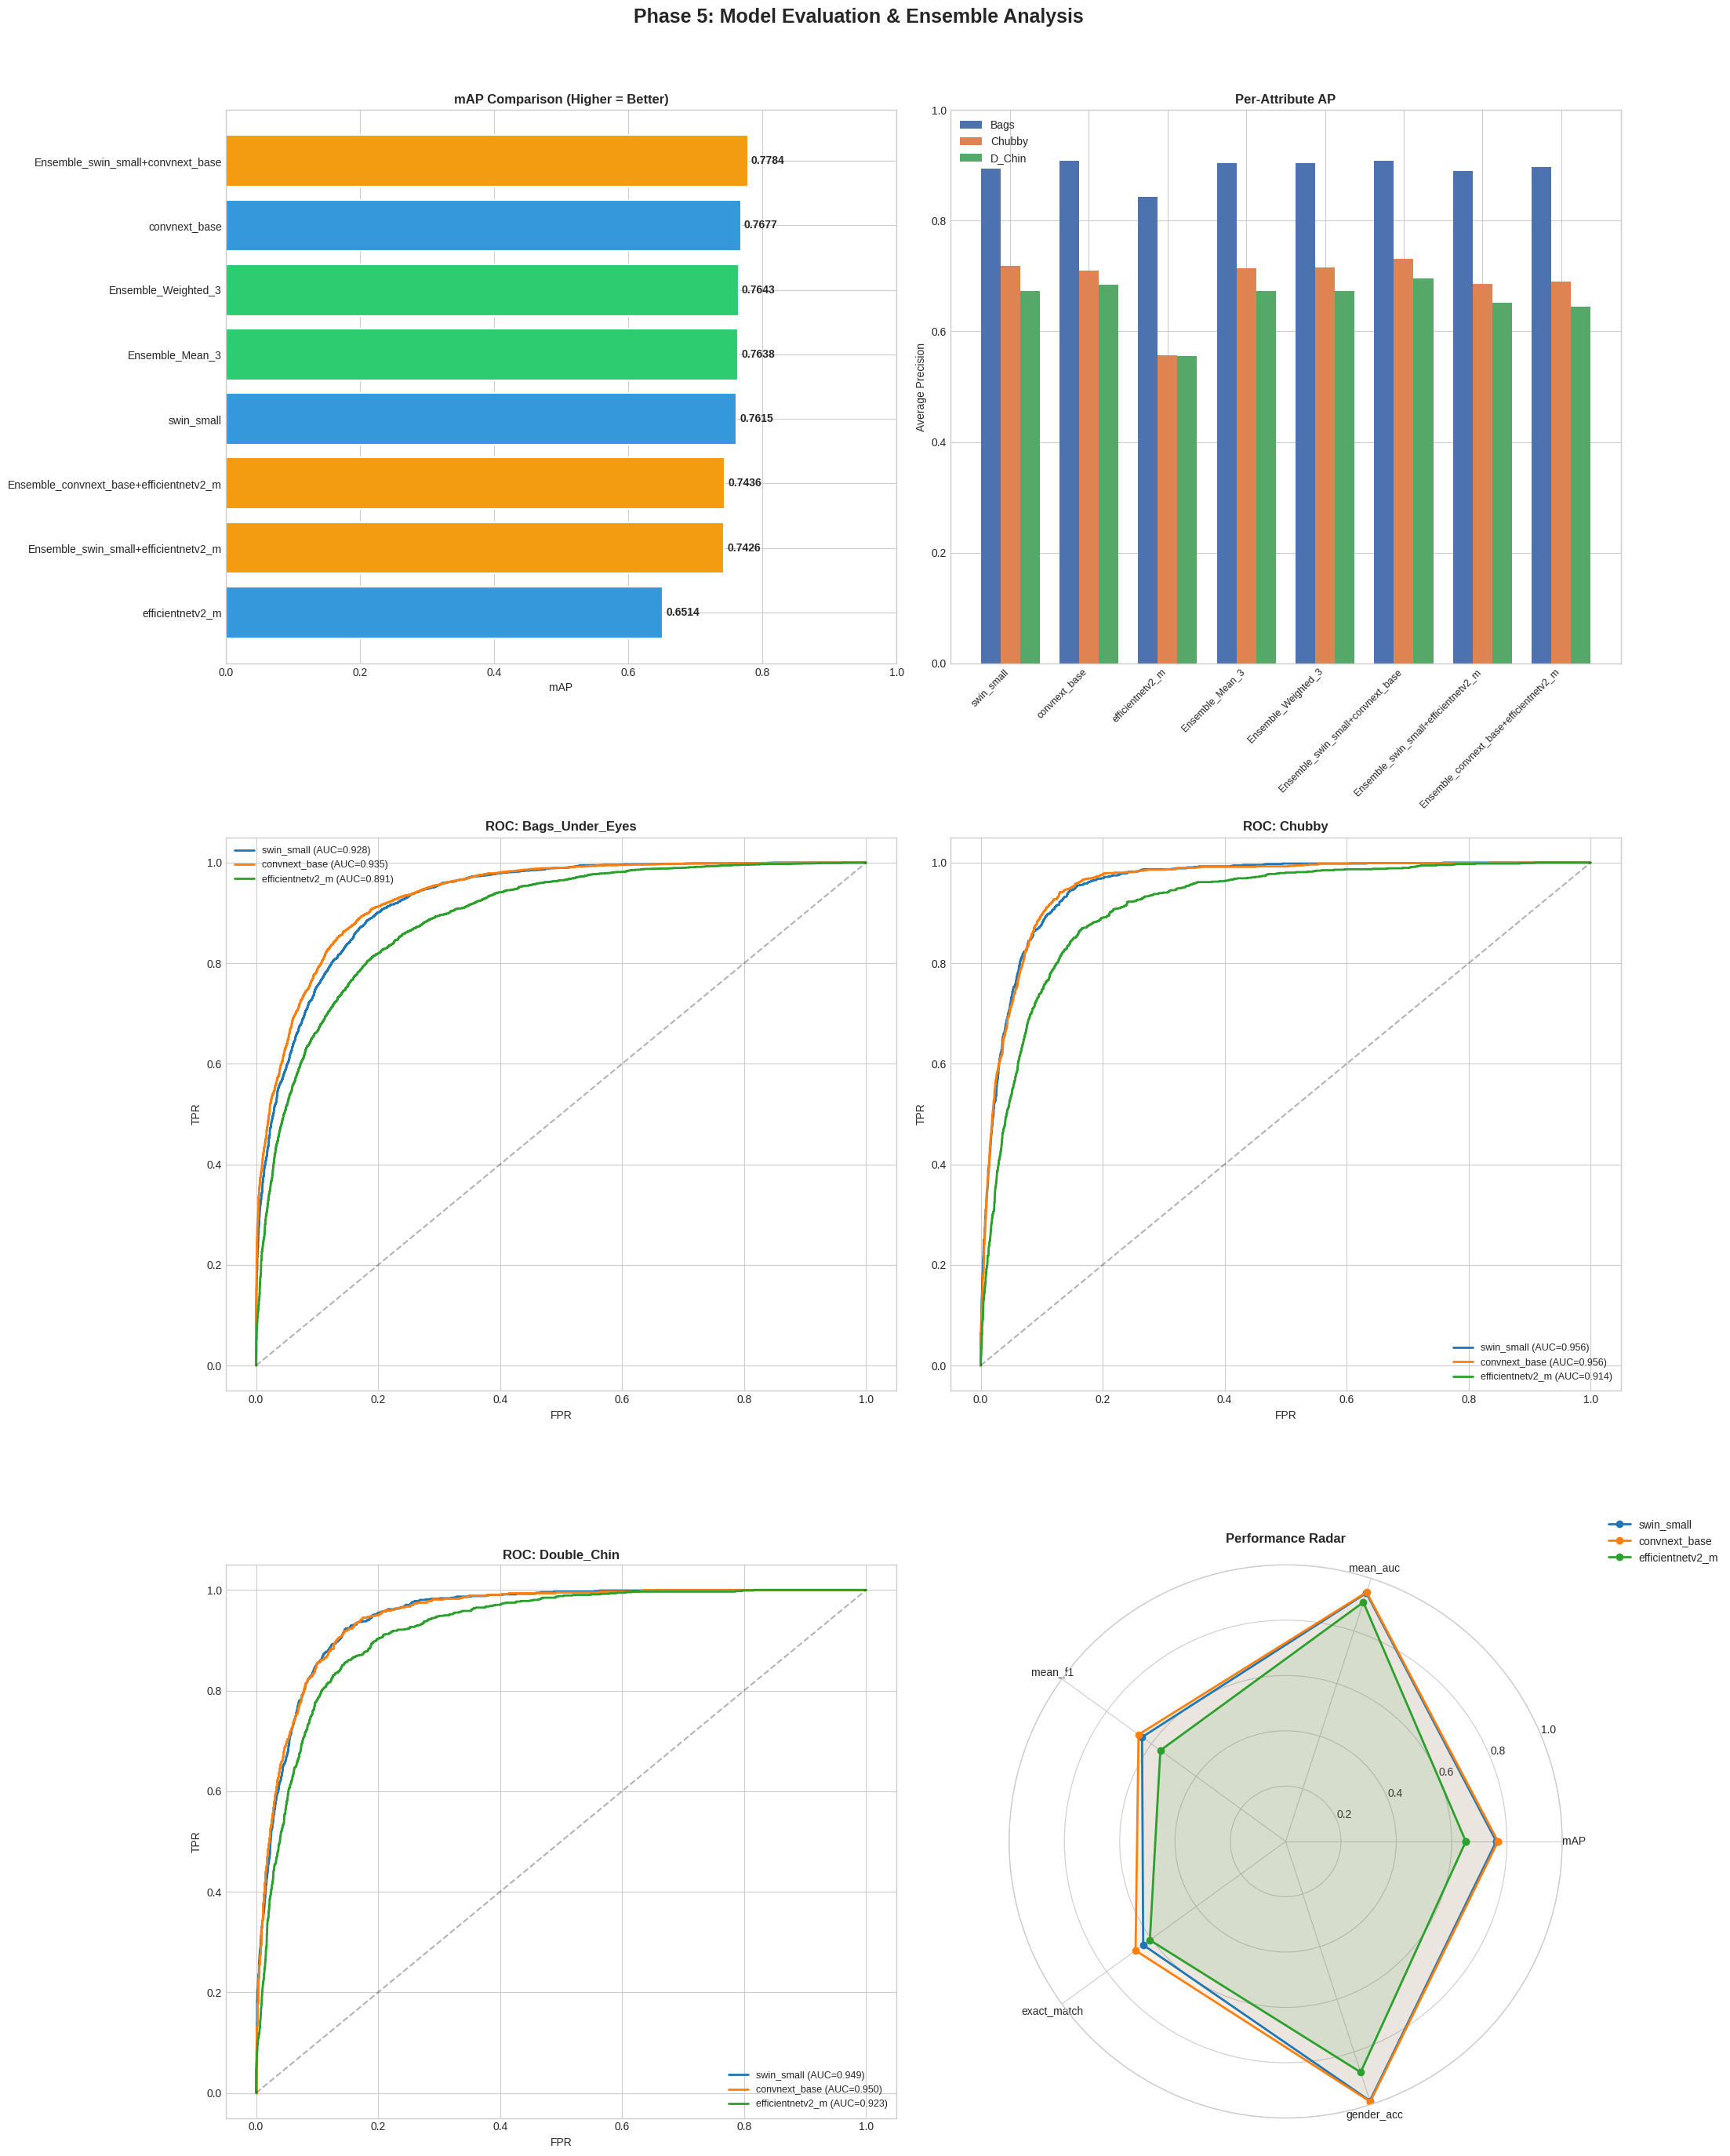

✓ Saved phase5_evaluation_plots.png


In [8]:
# ============================================================
# PHASE 6: VISUALIZATIONS
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

fig = plt.figure(figsize=(22, 28))
fig.suptitle("Phase 5: Model Evaluation & Ensemble Analysis", fontsize=18, fontweight="bold", y=0.98)

# --- PLOT 1: mAP Bar Chart (Models + Ensembles) ---
ax1 = fig.add_subplot(3, 2, 1)
plot_df = df_all.sort_values("mAP", ascending=True)
colors = []
for m in plot_df["Model"]:
    if "Ensemble" in m:
        colors.append("#2ECC71" if "Mean_3" in m or "Weighted_3" in m else "#F39C12")
    else:
        colors.append("#3498DB")
bars = ax1.barh(plot_df["Model"], plot_df["mAP"], color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, plot_df["mAP"]):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", 
             va="center", fontsize=10, fontweight="bold")
ax1.set_xlim(0, 1)
ax1.set_title("mAP Comparison (Higher = Better)", fontweight="bold")
ax1.set_xlabel("mAP")

# --- PLOT 2: Per-Attribute AP (Grouped) ---
ax2 = fig.add_subplot(3, 2, 2)
x = np.arange(len(df_all))
width = 0.25
ax2.bar(x - width, df_all["Bags_Under_Eyes_ap"], width, label="Bags", color="#4C72B0")
ax2.bar(x, df_all["Chubby_ap"], width, label="Chubby", color="#DD8452")
ax2.bar(x + width, df_all["Double_Chin_ap"], width, label="D_Chin", color="#55A868")
ax2.set_xticks(x)
ax2.set_xticklabels(df_all["Model"], rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Average Precision")
ax2.set_title("Per-Attribute AP", fontweight="bold")
ax2.legend()
ax2.set_ylim(0, 1)

# --- PLOT 3: ROC Curves (Bags_Under_Eyes) ---
ax3 = fig.add_subplot(3, 2, 3)
for model_name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(preds["targets"][:,0], preds["attr_probs"][:,0])
    auc = roc_auc_score(preds["targets"][:,0], preds["attr_probs"][:,0])
    ax3.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})", linewidth=2)
# Add best ensemble
best_ens = df_ensemble.loc[df_ensemble["mAP"].idxmax(), "Model"]
if "Mean_3" in best_ens:
    fpr, tpr, _ = roc_curve(targets[:,0], mean_3_prob[:,0])
    auc = roc_auc_score(targets[:,0], mean_3_prob[:,0])
    ax3.plot(fpr, tpr, "--", label=f"Ensemble (AUC={auc:.3f})", linewidth=2.5, color="black")
ax3.plot([0,1],[0,1],"k--",alpha=0.3)
ax3.set_xlabel("FPR")
ax3.set_ylabel("TPR")
ax3.set_title("ROC: Bags_Under_Eyes", fontweight="bold")
ax3.legend(fontsize=9)

# --- PLOT 4: ROC Curves (Chubby) ---
ax4 = fig.add_subplot(3, 2, 4)
for model_name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(preds["targets"][:,1], preds["attr_probs"][:,1])
    auc = roc_auc_score(preds["targets"][:,1], preds["attr_probs"][:,1])
    ax4.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})", linewidth=2)
if "Mean_3" in best_ens:
    fpr, tpr, _ = roc_curve(targets[:,1], mean_3_prob[:,1])
    auc = roc_auc_score(targets[:,1], mean_3_prob[:,1])
    ax4.plot(fpr, tpr, "--", label=f"Ensemble (AUC={auc:.3f})", linewidth=2.5, color="black")
ax4.plot([0,1],[0,1],"k--",alpha=0.3)
ax4.set_xlabel("FPR")
ax4.set_ylabel("TPR")
ax4.set_title("ROC: Chubby", fontweight="bold")
ax4.legend(fontsize=9)

# --- PLOT 5: ROC Curves (Double_Chin) ---
ax5 = fig.add_subplot(3, 2, 5)
for model_name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(preds["targets"][:,2], preds["attr_probs"][:,2])
    auc = roc_auc_score(preds["targets"][:,2], preds["attr_probs"][:,2])
    ax5.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})", linewidth=2)
if "Mean_3" in best_ens:
    fpr, tpr, _ = roc_curve(targets[:,2], mean_3_prob[:,2])
    auc = roc_auc_score(targets[:,2], mean_3_prob[:,2])
    ax5.plot(fpr, tpr, "--", label=f"Ensemble (AUC={auc:.3f})", linewidth=2.5, color="black")
ax5.plot([0,1],[0,1],"k--",alpha=0.3)
ax5.set_xlabel("FPR")
ax5.set_ylabel("TPR")
ax5.set_title("ROC: Double_Chin", fontweight="bold")
ax5.legend(fontsize=9)

# --- PLOT 6: Radar / Spider Chart of Key Metrics ---
ax6 = fig.add_subplot(3, 2, 6, polar=True)
categories = ["mAP", "mean_auc", "mean_f1", "exact_match", "gender_acc"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for model_name, preds in model_preds.items():
    m = compute_metrics(preds["attr_probs"], preds["targets"], preds["gender_probs"], preds["genders"])
    values = [m[c] for c in categories]
    values += values[:1]
    ax6.plot(angles, values, "o-", linewidth=2, label=model_name)
    ax6.fill(angles, values, alpha=0.1)

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories)
ax6.set_ylim(0, 1)
ax6.set_title("Performance Radar", fontweight="bold", pad=20)
ax6.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(WORKING_DIR / "phase5_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved phase5_evaluation_plots.png")

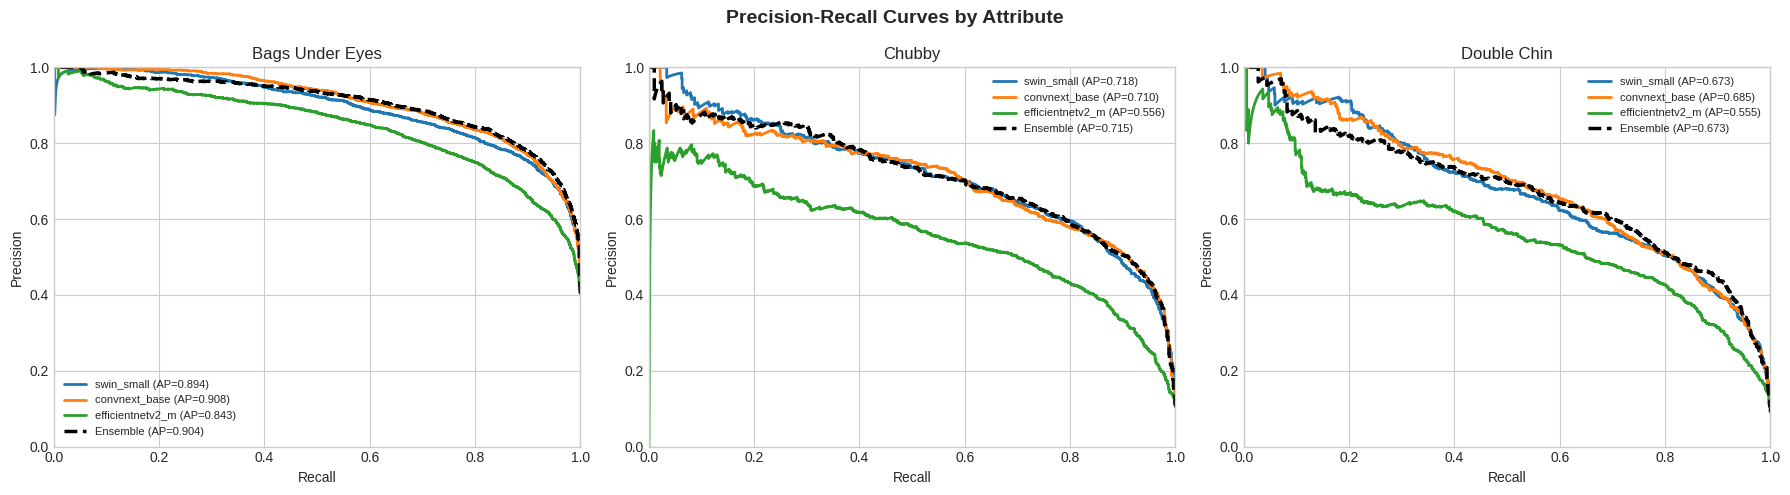

In [9]:
# ============================================================
# PHASE 5 — CELL 7: PRECISION-RECALL CURVES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Precision-Recall Curves by Attribute", fontsize=14, fontweight="bold")

for idx, (attr, ax) in enumerate(zip(TARGET_ATTRS, axes)):
    for model_name, preds in model_preds.items():
        precision, recall, _ = precision_recall_curve(preds["targets"][:,idx], preds["attr_probs"][:,idx])
        ap = average_precision_score(preds["targets"][:,idx], preds["attr_probs"][:,idx])
        ax.plot(recall, precision, linewidth=2, label=f"{model_name} (AP={ap:.3f})")
    
    # Ensemble
    if "mean_3_prob" in globals():
        precision, recall, _ = precision_recall_curve(targets[:,idx], mean_3_prob[:,idx])
        ap = average_precision_score(targets[:,idx], mean_3_prob[:,idx])
        ax.plot(recall, precision, "--", linewidth=2.5, color="black", label=f"Ensemble (AP={ap:.3f})")
    
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(attr.replace("_", " "))
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(WORKING_DIR / "phase5_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

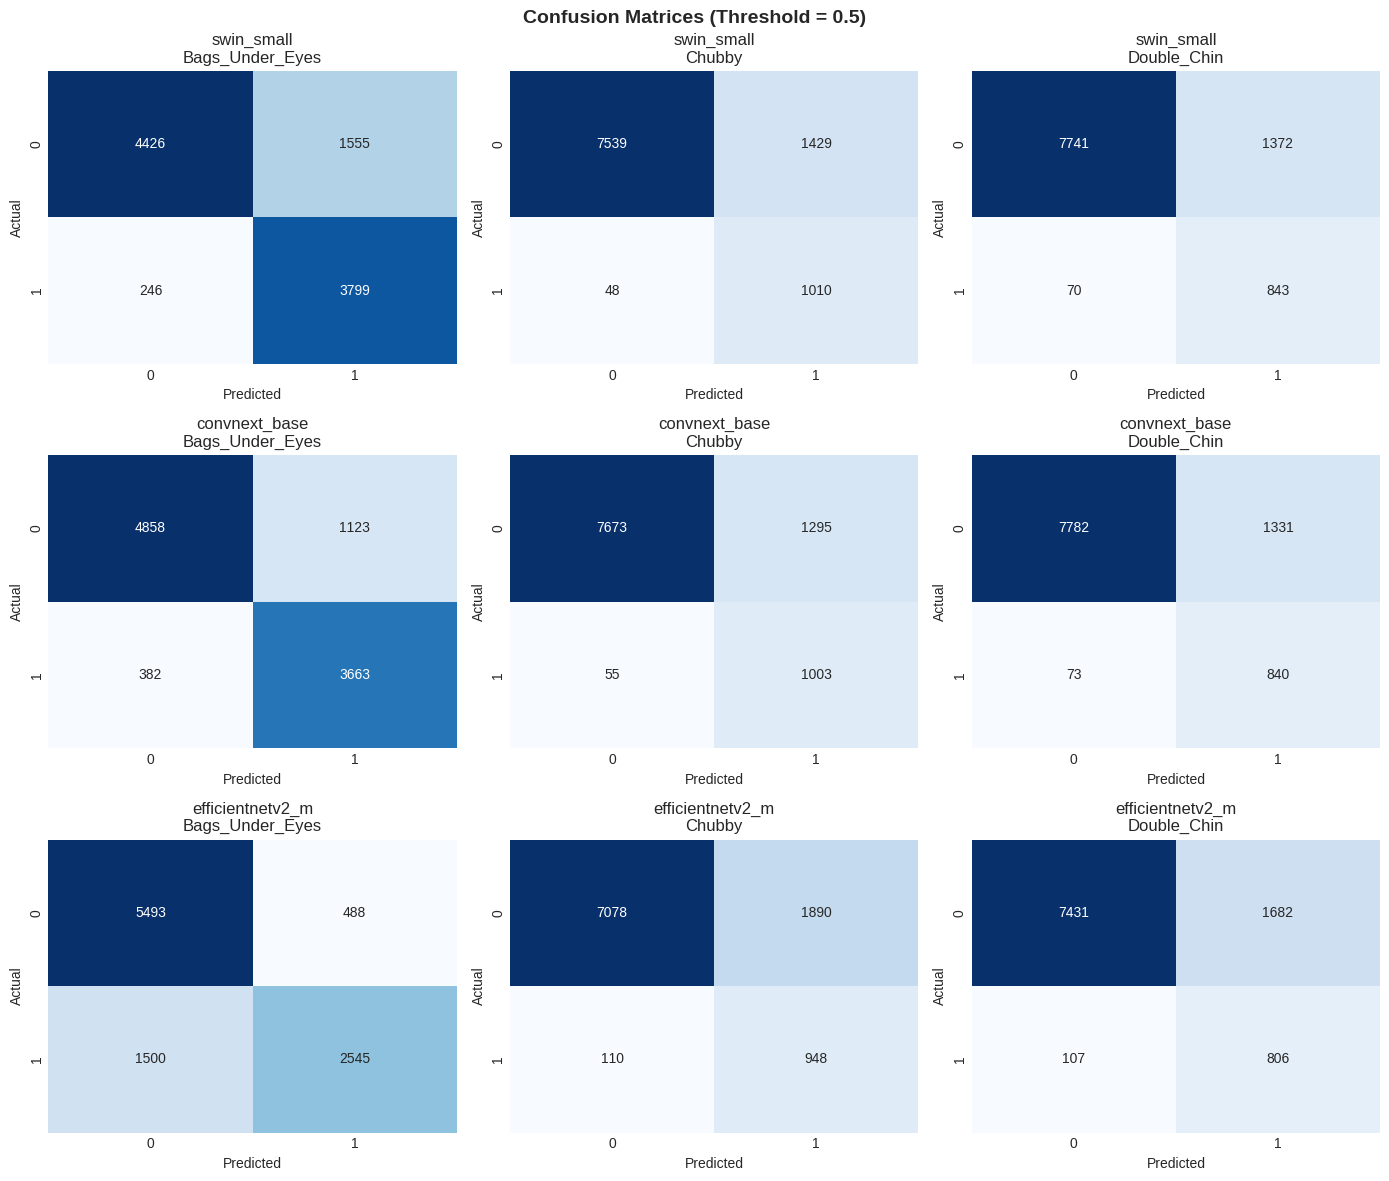

In [10]:
# ============================================================
# PHASE 5 — CELL 8: CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle("Confusion Matrices (Threshold = 0.5)", fontsize=14, fontweight="bold")

for row, (model_name, preds) in enumerate(model_preds.items()):
    for col, attr in enumerate(TARGET_ATTRS):
        ax = axes[row, col]
        yt = preds["targets"][:, col]
        yp = (preds["attr_probs"][:, col] >= 0.5).astype(int)
        cm = confusion_matrix(yt, yp)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
        ax.set_title(f"{model_name}\n{attr}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(WORKING_DIR / "phase5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()